# PEM full discharge analysis

This notebook documents the PEM/RFC full charge and discharge measurements used to evaluate charge input, discharge output and energy balance. It is part of the bachelor project "Investigation of reversible electrolyzers and implementation of energy management control strategies through IoT embedded microcontroller".

The notebook is kept as an experimental analysis notebook. The code cells below are unchanged; the markdown explains the purpose, method and interpretation of the existing calculations.

## Full discharge test

The first calculation uses `discharge_PEM_full.csv`. The data is cleaned by parsing timestamps, keeping valid INA4 voltage/current/power rows and sorting the samples in time. Current and power are separated into charge input and discharge output by sign, then integrated over time to estimate accumulated charge and energy.

This section is used to inspect the total electrical input and output of the PEM/RFC over a full discharge-oriented test.


================ PEM CHARGE / DISCHARGE SUMMARY ================

                Metric       Value  Unit
    Total charge input   50.535007   mAh
   Total charge output   11.523472   mAh
Current-counting ratio   22.802950     %
    Total energy input   81.798611   mWh
   Total energy output    0.000000   mWh
          Energy ratio    0.000000     %
           Max voltage    1.507500     V
           Min voltage    0.000000     V
           Max current  178.500000    mA
           Min current -119.475000    mA
             Max power  269.375000    mW
             Min power    0.000000    mW
         Test duration    0.511389 hours


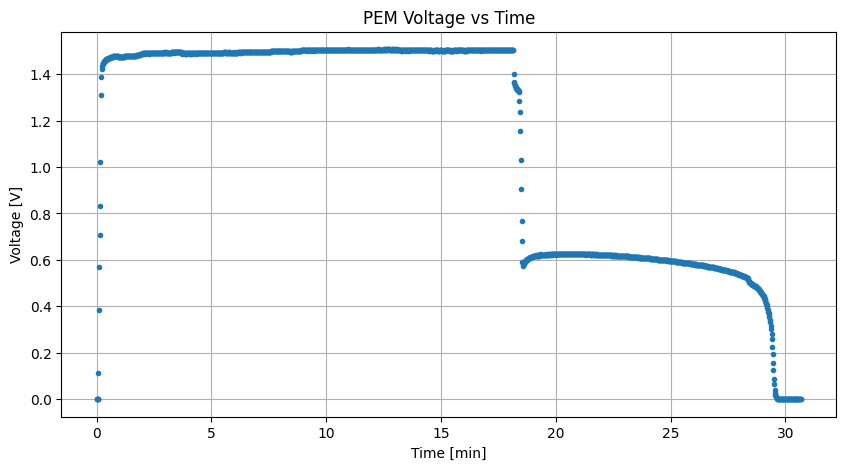

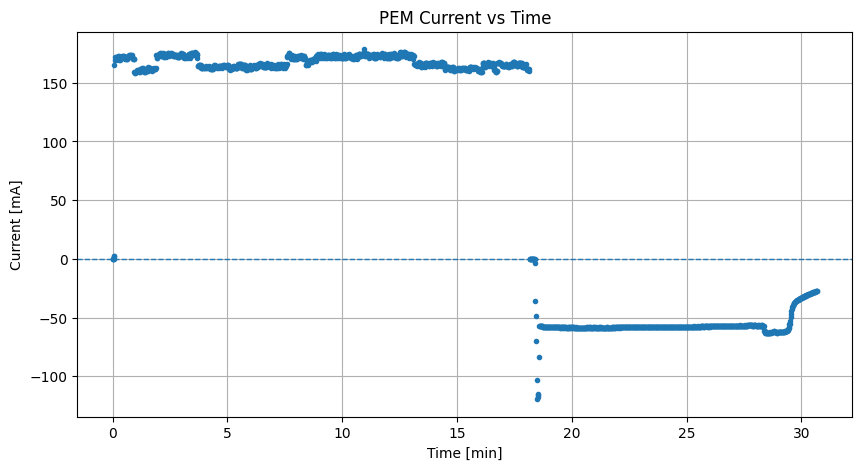

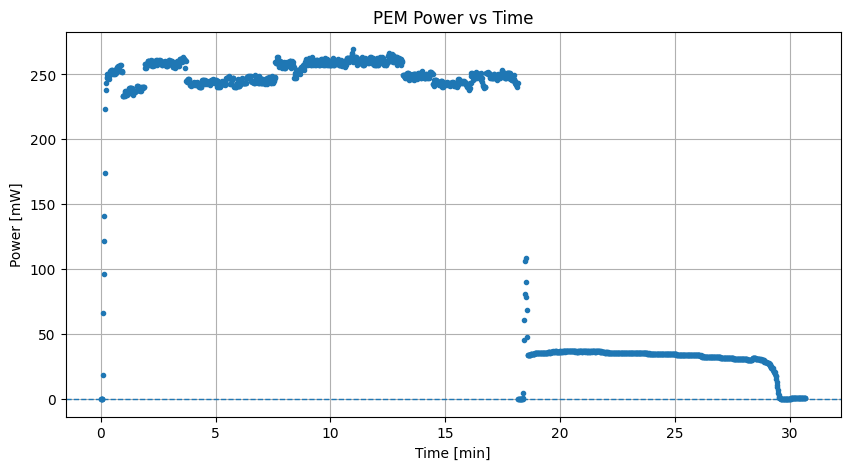

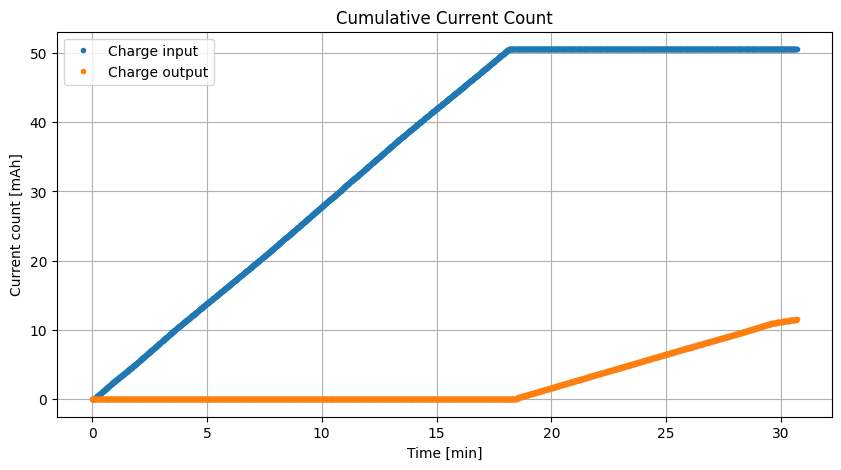

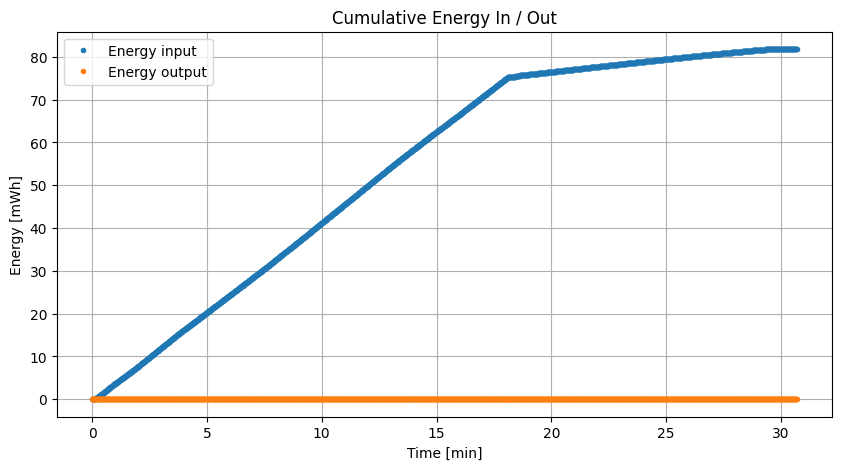

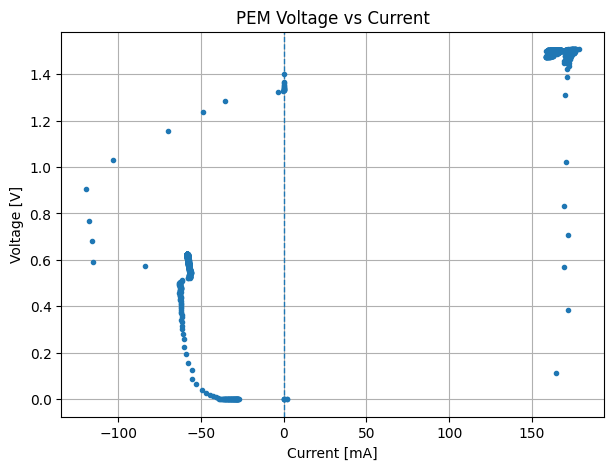

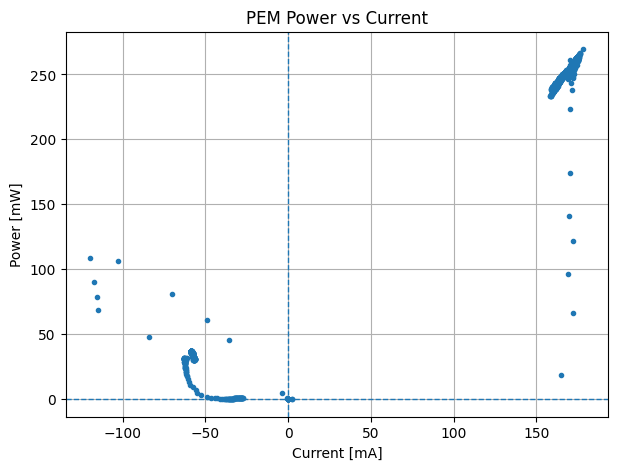

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

CSV_FILE = "discharge_PEM_full.csv"

V_COL = "ina4_bus_V"
I_COL = "ina4_current_mA"
P_COL = "ina4_power_mW"
TIME_COL = "timestamp"

# If your signs are reversed, set this to True
REVERSE_SIGN = False

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_FILE)

# Convert timestamp to datetime
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

# Keep only rows with valid time and INA4 values
df = df.dropna(subset=[TIME_COL, V_COL, I_COL, P_COL]).copy()

# Sort by time
df = df.sort_values(TIME_COL).reset_index(drop=True)

# Convert to seconds from start
df["time_s"] = (df[TIME_COL] - df[TIME_COL].iloc[0]).dt.total_seconds()
df["time_min"] = df["time_s"] / 60
df["time_h"] = df["time_s"] / 3600

# Convert units
df["voltage_V"] = df[V_COL]
df["current_A"] = df[I_COL] / 1000
df["power_W"] = df[P_COL] / 1000

if REVERSE_SIGN:
    df["current_A"] *= -1
    df["power_W"] *= -1

# Time difference between samples
df["dt_s"] = df["time_s"].diff().fillna(0)

# Remove strange negative or very large time jumps if present
df.loc[df["dt_s"] < 0, "dt_s"] = 0

# ============================================================
# CURRENT COUNTING AND ENERGY CALCULATION
# ============================================================

# Positive values = charging / energy into PEM cell
df["current_in_A"] = df["current_A"].clip(lower=0)
df["power_in_W"] = df["power_W"].clip(lower=0)

# Negative values = discharging / energy extracted from PEM cell
df["current_out_A"] = (-df["current_A"].clip(upper=0))
df["power_out_W"] = (-df["power_W"].clip(upper=0))

# Charge in Ah and mAh
df["charge_in_Ah_step"] = df["current_in_A"] * df["dt_s"] / 3600
df["charge_out_Ah_step"] = df["current_out_A"] * df["dt_s"] / 3600

df["charge_in_mAh_cum"] = df["charge_in_Ah_step"].cumsum() * 1000
df["charge_out_mAh_cum"] = df["charge_out_Ah_step"].cumsum() * 1000

# Energy in Wh and mWh
df["energy_in_Wh_step"] = df["power_in_W"] * df["dt_s"] / 3600
df["energy_out_Wh_step"] = df["power_out_W"] * df["dt_s"] / 3600

df["energy_in_mWh_cum"] = df["energy_in_Wh_step"].cumsum() * 1000
df["energy_out_mWh_cum"] = df["energy_out_Wh_step"].cumsum() * 1000

# Total values
total_charge_in_mAh = df["charge_in_Ah_step"].sum() * 1000
total_charge_out_mAh = df["charge_out_Ah_step"].sum() * 1000

total_energy_in_mWh = df["energy_in_Wh_step"].sum() * 1000
total_energy_out_mWh = df["energy_out_Wh_step"].sum() * 1000

# Efficiencies / ratios
coulomb_ratio_pct = 100 * total_charge_out_mAh / total_charge_in_mAh if total_charge_in_mAh > 0 else np.nan
energy_ratio_pct = 100 * total_energy_out_mWh / total_energy_in_mWh if total_energy_in_mWh > 0 else np.nan

# ============================================================
# SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Total charge input",
        "Total charge output",
        "Current-counting ratio",
        "Total energy input",
        "Total energy output",
        "Energy ratio",
        "Max voltage",
        "Min voltage",
        "Max current",
        "Min current",
        "Max power",
        "Min power",
        "Test duration"
    ],
    "Value": [
        total_charge_in_mAh,
        total_charge_out_mAh,
        coulomb_ratio_pct,
        total_energy_in_mWh,
        total_energy_out_mWh,
        energy_ratio_pct,
        df["voltage_V"].max(),
        df["voltage_V"].min(),
        df["current_A"].max() * 1000,
        df["current_A"].min() * 1000,
        df["power_W"].max() * 1000,
        df["power_W"].min() * 1000,
        df["time_h"].iloc[-1]
    ],
    "Unit": [
        "mAh",
        "mAh",
        "%",
        "mWh",
        "mWh",
        "%",
        "V",
        "V",
        "mA",
        "mA",
        "mW",
        "mW",
        "hours"
    ]
})

print("\n================ PEM CHARGE / DISCHARGE SUMMARY ================\n")
print(summary.to_string(index=False))

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["voltage_V"], marker=".", linestyle="None")
plt.xlabel("Time [min]")
plt.ylabel("Voltage [V]")
plt.title("PEM Voltage vs Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["current_A"] * 1000, marker=".", linestyle="None")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time [min]")
plt.ylabel("Current [mA]")
plt.title("PEM Current vs Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["power_W"] * 1000, marker=".", linestyle="None")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time [min]")
plt.ylabel("Power [mW]")
plt.title("PEM Power vs Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["charge_in_mAh_cum"], marker=".", linestyle="None", label="Charge input")
plt.plot(df["time_min"], df["charge_out_mAh_cum"], marker=".", linestyle="None", label="Charge output")
plt.xlabel("Time [min]")
plt.ylabel("Current count [mAh]")
plt.title("Cumulative Current Count")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["energy_in_mWh_cum"], marker=".", linestyle="None", label="Energy input")
plt.plot(df["time_min"], df["energy_out_mWh_cum"], marker=".", linestyle="None", label="Energy output")
plt.xlabel("Time [min]")
plt.ylabel("Energy [mWh]")
plt.title("Cumulative Energy In / Out")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df["current_A"] * 1000, df["voltage_V"], marker=".", linestyle="None")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Current [mA]")
plt.ylabel("Voltage [V]")
plt.title("PEM Voltage vs Current")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df["current_A"] * 1000, df["power_W"] * 1000, marker=".", linestyle="None")
plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Current [mA]")
plt.ylabel("Power [mW]")
plt.title("PEM Power vs Current")
plt.grid(True)
plt.show()

## Combined full and half-cycle test

The second calculation uses `PEM_full_charge_discharge_and_half_charge_discharge.csv`. It applies the same unit conversion and integration method, but also removes a manually identified standby interval and segments the remaining data into active charge and discharge periods.

This makes the analysis suitable for comparing repeated PEM/RFC operating phases and checking whether the measured charge and discharge behaviour is consistent across the test.


================ PEM CHARGE / DISCHARGE SUMMARY ================

                Metric      Value  Unit
    Total charge input  90.469257   mAh
   Total charge output  23.037042   mAh
Current-counting ratio  25.463945     %
    Total energy input 150.289062   mWh
   Total energy output   0.000000   mWh
          Energy ratio   0.000000     %
           Max voltage   1.525000     V
           Min voltage   0.000000     V
           Max current 207.500000    mA
           Min current -63.525000    mA
             Max power 316.250000    mW
             Min power   0.000000    mW
         Test duration   1.060556 hours

================ INDIVIDUAL CHARGE / DISCHARGE CYCLES ================

 Cycle number     State  Start [min]  End [min]  Duration [min]  Charge [mAh]  Energy [mWh]  Avg current [mA]  Avg power [mW]  Start voltage [V]  End voltage [V]
            1    Charge     0.050000  15.300000       15.250000     48.653944     73.406944        191.443750      288.724078             

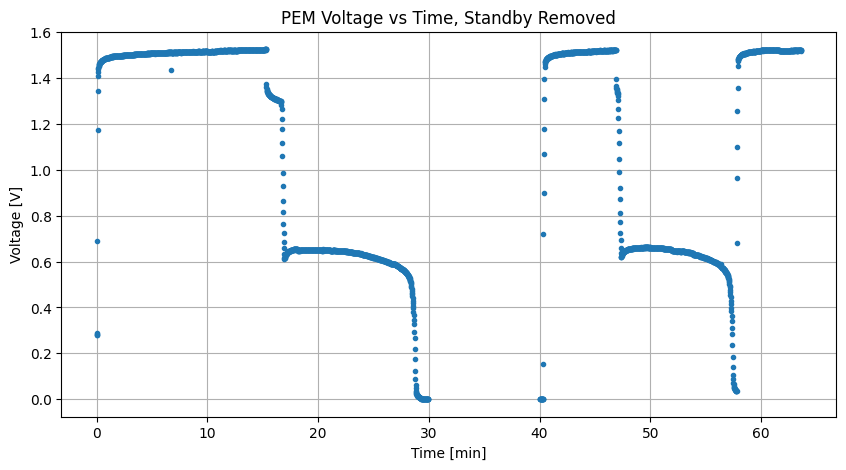

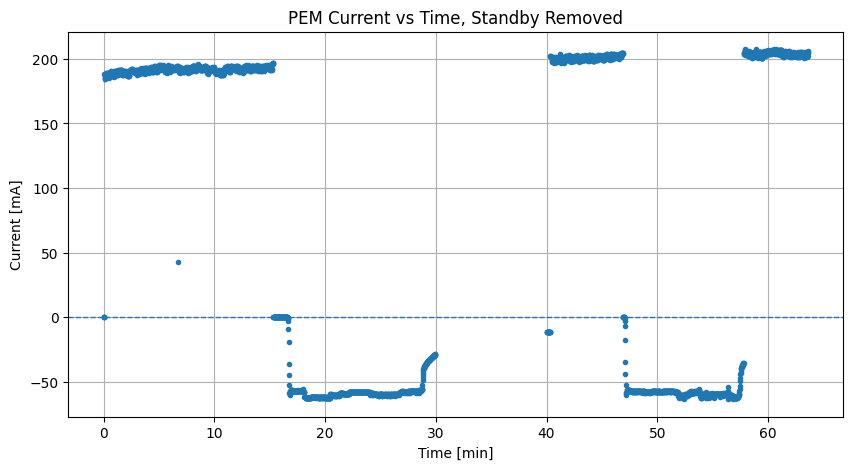

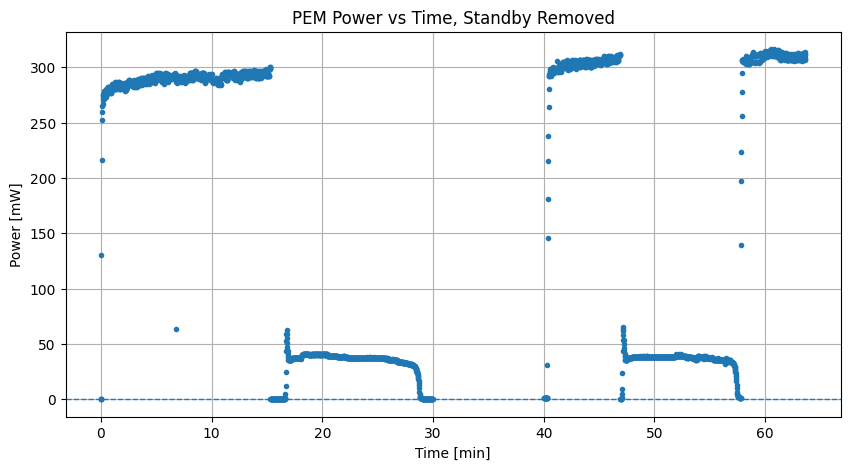

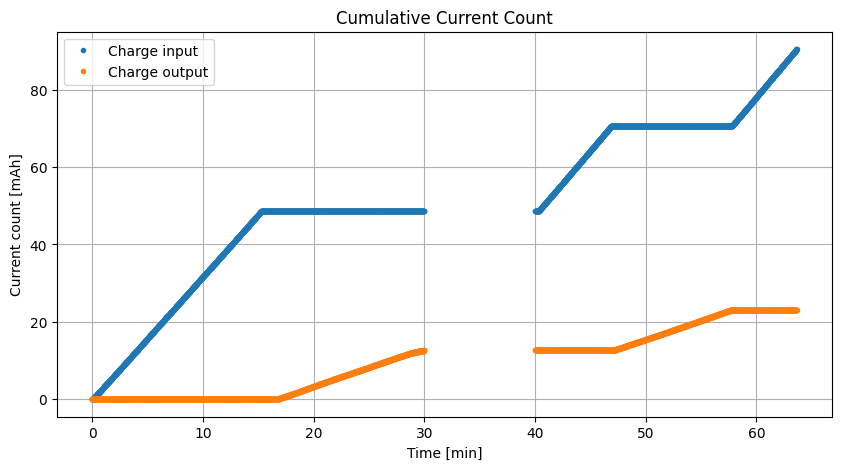

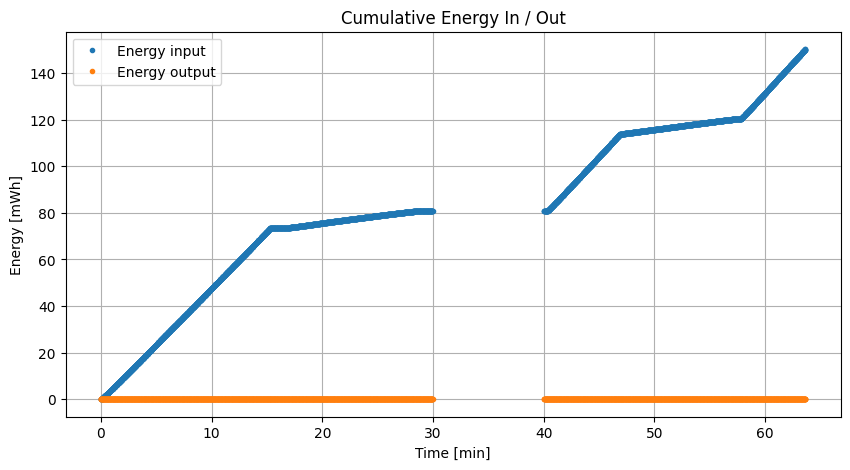

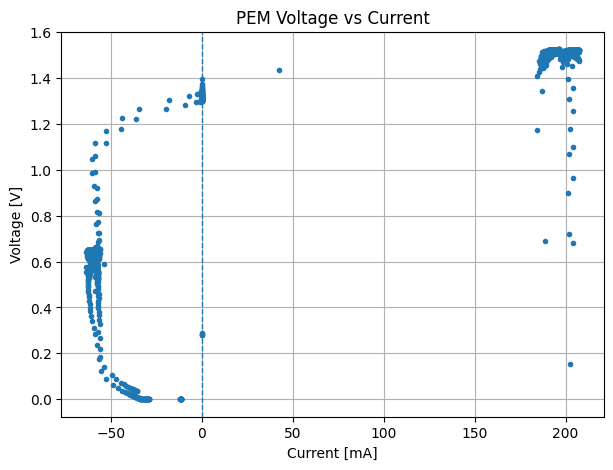

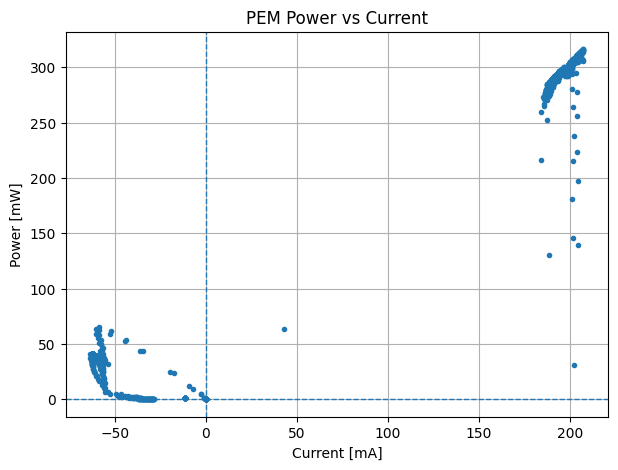

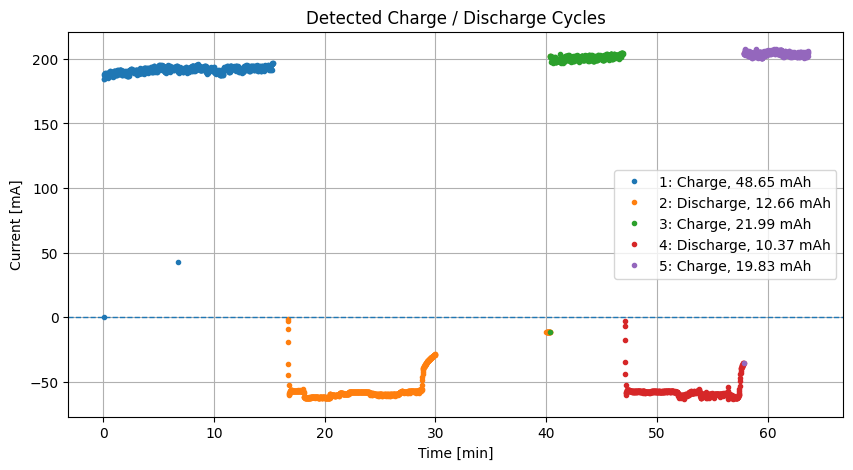

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

CSV_FILE = "PEM_full_charge_discharge_and_half_charge_discharge.csv"

V_COL = "ina4_bus_V"
I_COL = "ina4_current_mA"
P_COL = "ina4_power_mW"
TIME_COL = "timestamp"

# If your signs are reversed, set this to True
REVERSE_SIGN = False

# Current threshold used to detect standby / idle
# Values between -IDLE_CURRENT_mA and +IDLE_CURRENT_mA are treated as standby
IDLE_CURRENT_mA = 1.0

# Remove standby region manually
REMOVE_STANDBY_REGION = True
STANDBY_START_MIN = 30
STANDBY_END_MIN = 40

# Minimum duration of a cycle to keep
# This helps remove very short noise-based segments
MIN_SEGMENT_DURATION_S = 2

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_FILE)

# Convert timestamp to datetime
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

# Keep only rows with valid time and INA4 values
df = df.dropna(subset=[TIME_COL, V_COL, I_COL, P_COL]).copy()

# Sort by time
df = df.sort_values(TIME_COL).reset_index(drop=True)

# Convert to seconds from start
df["time_s"] = (df[TIME_COL] - df[TIME_COL].iloc[0]).dt.total_seconds()
df["time_min"] = df["time_s"] / 60
df["time_h"] = df["time_s"] / 3600

# Convert units
df["voltage_V"] = df[V_COL]
df["current_A"] = df[I_COL] / 1000
df["power_W"] = df[P_COL] / 1000

if REVERSE_SIGN:
    df["current_A"] *= -1
    df["power_W"] *= -1

# ============================================================
# REMOVE STANDBY BETWEEN 30 AND 40 MIN
# ============================================================

if REMOVE_STANDBY_REGION:
    df = df[
        ~(
            (df["time_min"] >= STANDBY_START_MIN)
            & (df["time_min"] <= STANDBY_END_MIN)
        )
    ].copy()

# Reset index after removal
df = df.reset_index(drop=True)

# Recalculate time difference between samples
df["dt_s"] = df["time_s"].diff().fillna(0)

# Remove strange negative or very large time jumps if present
df.loc[df["dt_s"] < 0, "dt_s"] = 0

# Important:
# After removing 30-40 min, there will be a large dt_s jump.
# We do NOT want that jump to be included in the integration.
# Therefore, set large gaps to zero.
MAX_REASONABLE_DT_S = 5
df.loc[df["dt_s"] > MAX_REASONABLE_DT_S, "dt_s"] = 0

# ============================================================
# CURRENT COUNTING AND ENERGY CALCULATION
# ============================================================

# Positive values = charging / energy into PEM cell
df["current_in_A"] = df["current_A"].clip(lower=0)
df["power_in_W"] = df["power_W"].clip(lower=0)

# Negative values = discharging / energy extracted from PEM cell
df["current_out_A"] = -df["current_A"].clip(upper=0)
df["power_out_W"] = -df["power_W"].clip(upper=0)

# Charge in Ah and mAh
df["charge_in_Ah_step"] = df["current_in_A"] * df["dt_s"] / 3600
df["charge_out_Ah_step"] = df["current_out_A"] * df["dt_s"] / 3600

df["charge_in_mAh_cum"] = df["charge_in_Ah_step"].cumsum() * 1000
df["charge_out_mAh_cum"] = df["charge_out_Ah_step"].cumsum() * 1000

# Energy in Wh and mWh
df["energy_in_Wh_step"] = df["power_in_W"] * df["dt_s"] / 3600
df["energy_out_Wh_step"] = df["power_out_W"] * df["dt_s"] / 3600

df["energy_in_mWh_cum"] = df["energy_in_Wh_step"].cumsum() * 1000
df["energy_out_mWh_cum"] = df["energy_out_Wh_step"].cumsum() * 1000

# ============================================================
# AUTOMATIC CHARGE / DISCHARGE CYCLE DETECTION
# ============================================================

def classify_state(current_mA, idle_threshold_mA):
    if current_mA > idle_threshold_mA:
        return "Charge"
    elif current_mA < -idle_threshold_mA:
        return "Discharge"
    else:
        return "Standby"

df["current_mA"] = df["current_A"] * 1000
df["state"] = df["current_mA"].apply(
    lambda x: classify_state(x, IDLE_CURRENT_mA)
)

# Create segment ID whenever state changes
df["segment_id"] = (df["state"] != df["state"].shift()).cumsum()

segment_rows = []

for segment_id, g in df.groupby("segment_id"):
    state = g["state"].iloc[0]

    start_min = g["time_min"].iloc[0]
    end_min = g["time_min"].iloc[-1]
    duration_s = g["dt_s"].sum()

    if duration_s < MIN_SEGMENT_DURATION_S:
        continue

    if state == "Charge":
        charge_mAh = g["charge_in_Ah_step"].sum() * 1000
        energy_mWh = g["energy_in_Wh_step"].sum() * 1000
        avg_current_mA = g["current_mA"].mean()
        avg_power_mW = g["power_W"].mean() * 1000

    elif state == "Discharge":
        charge_mAh = g["charge_out_Ah_step"].sum() * 1000
        energy_mWh = g["energy_out_Wh_step"].sum() * 1000
        avg_current_mA = g["current_mA"].mean()
        avg_power_mW = g["power_W"].mean() * 1000

    else:
        charge_mAh = 0
        energy_mWh = 0
        avg_current_mA = g["current_mA"].mean()
        avg_power_mW = g["power_W"].mean() * 1000

    segment_rows.append({
        "Segment": segment_id,
        "State": state,
        "Start [min]": start_min,
        "End [min]": end_min,
        "Duration [min]": duration_s / 60,
        "Charge [mAh]": charge_mAh,
        "Energy [mWh]": energy_mWh,
        "Avg current [mA]": avg_current_mA,
        "Avg power [mW]": avg_power_mW,
        "Start voltage [V]": g["voltage_V"].iloc[0],
        "End voltage [V]": g["voltage_V"].iloc[-1],
    })

segments = pd.DataFrame(segment_rows)

# Keep only charge and discharge segments for the cycle table
cycle_summary = segments[segments["State"].isin(["Charge", "Discharge"])].copy()
cycle_summary = cycle_summary.reset_index(drop=True)
cycle_summary["Cycle number"] = cycle_summary.index + 1

# Reorder columns
cycle_summary = cycle_summary[
    [
        "Cycle number",
        "State",
        "Start [min]",
        "End [min]",
        "Duration [min]",
        "Charge [mAh]",
        "Energy [mWh]",
        "Avg current [mA]",
        "Avg power [mW]",
        "Start voltage [V]",
        "End voltage [V]",
    ]
]

# ============================================================
# TOTAL VALUES
# ============================================================

total_charge_in_mAh = df["charge_in_Ah_step"].sum() * 1000
total_charge_out_mAh = df["charge_out_Ah_step"].sum() * 1000

total_energy_in_mWh = df["energy_in_Wh_step"].sum() * 1000
total_energy_out_mWh = df["energy_out_Wh_step"].sum() * 1000

coulomb_ratio_pct = (
    100 * total_charge_out_mAh / total_charge_in_mAh
    if total_charge_in_mAh > 0 else np.nan
)

energy_ratio_pct = (
    100 * total_energy_out_mWh / total_energy_in_mWh
    if total_energy_in_mWh > 0 else np.nan
)

# ============================================================
# SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Total charge input",
        "Total charge output",
        "Current-counting ratio",
        "Total energy input",
        "Total energy output",
        "Energy ratio",
        "Max voltage",
        "Min voltage",
        "Max current",
        "Min current",
        "Max power",
        "Min power",
        "Test duration",
    ],
    "Value": [
        total_charge_in_mAh,
        total_charge_out_mAh,
        coulomb_ratio_pct,
        total_energy_in_mWh,
        total_energy_out_mWh,
        energy_ratio_pct,
        df["voltage_V"].max(),
        df["voltage_V"].min(),
        df["current_A"].max() * 1000,
        df["current_A"].min() * 1000,
        df["power_W"].max() * 1000,
        df["power_W"].min() * 1000,
        df["time_h"].iloc[-1],
    ],
    "Unit": [
        "mAh",
        "mAh",
        "%",
        "mWh",
        "mWh",
        "%",
        "V",
        "V",
        "mA",
        "mA",
        "mW",
        "mW",
        "hours",
    ],
})

print("\n================ PEM CHARGE / DISCHARGE SUMMARY ================\n")
print(summary.to_string(index=False))

print("\n================ INDIVIDUAL CHARGE / DISCHARGE CYCLES ================\n")
print(cycle_summary.to_string(index=False))

# Optional: save cycle summary to CSV
cycle_summary.to_csv("PEM_cycle_summary.csv", index=False)

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["voltage_V"], marker=".", linestyle="None")
plt.xlabel("Time [min]")
plt.ylabel("Voltage [V]")
plt.title("PEM Voltage vs Time, Standby Removed")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["current_A"] * 1000, marker=".", linestyle="None")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time [min]")
plt.ylabel("Current [mA]")
plt.title("PEM Current vs Time, Standby Removed")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["power_W"] * 1000, marker=".", linestyle="None")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time [min]")
plt.ylabel("Power [mW]")
plt.title("PEM Power vs Time, Standby Removed")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["charge_in_mAh_cum"], marker=".", linestyle="None", label="Charge input")
plt.plot(df["time_min"], df["charge_out_mAh_cum"], marker=".", linestyle="None", label="Charge output")
plt.xlabel("Time [min]")
plt.ylabel("Current count [mAh]")
plt.title("Cumulative Current Count")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_min"], df["energy_in_mWh_cum"], marker=".", linestyle="None", label="Energy input")
plt.plot(df["time_min"], df["energy_out_mWh_cum"], marker=".", linestyle="None", label="Energy output")
plt.xlabel("Time [min]")
plt.ylabel("Energy [mWh]")
plt.title("Cumulative Energy In / Out")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df["current_A"] * 1000, df["voltage_V"], marker=".", linestyle="None")
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Current [mA]")
plt.ylabel("Voltage [V]")
plt.title("PEM Voltage vs Current")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df["current_A"] * 1000, df["power_W"] * 1000, marker=".", linestyle="None")
plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Current [mA]")
plt.ylabel("Power [mW]")
plt.title("PEM Power vs Current")
plt.grid(True)
plt.show()

# ============================================================
# EXTRA PLOT: DETECTED CYCLES
# ============================================================

plt.figure(figsize=(10, 5))

for _, row in cycle_summary.iterrows():
    mask = (
        (df["time_min"] >= row["Start [min]"])
        & (df["time_min"] <= row["End [min]"])
    )

    label = f'{int(row["Cycle number"])}: {row["State"]}, {row["Charge [mAh]"]:.2f} mAh'

    plt.plot(
        df.loc[mask, "time_min"],
        df.loc[mask, "current_mA"],
        marker=".",
        linestyle="None",
        label=label,
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time [min]")
plt.ylabel("Current [mA]")
plt.title("Detected Charge / Discharge Cycles")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

The notebook supports the EMS parameter selection by showing how INA226 current and power measurements can be integrated into charge and energy quantities. The most important outputs are the accumulated charge, accumulated energy and visual separation between charging, standby and discharge behaviour.

For thesis use, this notebook should be read as supporting experimental evidence. Final EMS constants should be taken from the documented control-parameter notebooks or from explicitly stated values in the thesis, with this notebook used to justify the measurement basis.